In [17]:
import torchvision
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import transforms

# 官方 CIFAR-100 均值和标准差
mean = (0.5071, 0.4867, 0.4408)
std = (0.2675, 0.2565, 0.2761)

# ToTensor + Normalize
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

In [21]:
device = torch.device("cuda")
print("Using device:", device)

loss_functions = {
    "CrossEntropy": torch.nn.CrossEntropyLoss(),
    "LabelSmoothing": torch.nn.CrossEntropyLoss(label_smoothing=0.1)
}
learning_rates = [0.01, 0.001, 0.0001]   # 学习率
batch_sizes = [64, 128, 256]         # batch

def train_resnet(loss_name, loss_fn, lr, batch_size, epochs=20):
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4)

    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.fc = torch.nn.Linear(512, 100)
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)

    train_losses, test_accs = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(trainloader)
        train_losses.append(avg_loss)

        # 测试
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        acc = 100 * correct / total
        test_accs.append(acc)
        # loss_name
        print(f"[Loss={loss_name}, lr={lr}, batch={batch_size}] Epoch {epoch+1}: Loss={avg_loss:.4f}, Acc={acc:.2f}%")

    return pd.DataFrame({"epoch": range(1, epochs+1), "train_loss": train_losses, "test_acc": test_accs})

# 循环
results = {}
for loss_name, loss_fn in loss_functions.items():
    for lr in learning_rates:
        for batch in batch_sizes:
            key = f"{loss_name}_lr{lr}_bs{batch}"
            if key in results:
                print(f"Skipping {key}, already done.")
                continue
            print(f"=== Running experiment: {key} ===")
            df = train_resnet(loss_name, loss_fn, lr, batch, epochs=20)
            results[key] = df
            df.to_csv(f"resnet18_{key}.csv", index=False)


Using device: cuda
=== Running experiment: CrossEntropy_lr0.01_bs64 ===
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 1: Loss=4.4700, Acc=7.19%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 2: Loss=3.7640, Acc=13.19%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 3: Loss=3.4090, Acc=17.65%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 4: Loss=3.1031, Acc=23.69%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 5: Loss=2.9089, Acc=24.32%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 6: Loss=2.7849, Acc=26.00%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 7: Loss=2.7110, Acc=26.97%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 8: Loss=2.6498, Acc=29.11%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 9: Loss=2.5974, Acc=29.92%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 10: Loss=2.5694, Acc=26.93%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 11: Loss=2.5378, Acc=31.77%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 12: Loss=2.5180, Acc=30.58%
[Loss=CrossEntropy, lr=0.01, batch=64] Epoch 13: Loss=2.4915, 

In [33]:
best_key = None
best_acc = 0.0

for key, df in results.items():
    final_acc = df["test_acc"].iloc[-1]   # 最后一轮的准确率
    if final_acc > best_acc:
        best_acc = final_acc
        best_key = key

print("最佳参数组合:", best_key, "最终测试集准确率:", best_acc)

最佳参数组合: LabelSmoothing_lr0.0001_bs64 最终测试集准确率: 56.7


In [29]:
def parse_key(key):
    """
    解析 key
    返回 dict: {"loss":..., "lr":..., "bs":...}
    """
    info = {}
    parts = key.split("_")
    for p in parts:
        if "=" in p:  # 格式 loss=CrossEntropy
            k, v = p.split("=")
            info[k] = v
        elif p.startswith("lr"):
            info["lr"] = p.replace("lr", "")
        elif p.startswith("bs"):
            info["bs"] = p.replace("bs", "")
        elif "Entropy" in p or "Smoothing" in p:  # 简单判断loss名字
            info["loss"] = p
    return info

def plot_grouped_results(results, metric="test_acc", group_by="loss"):
    parsed = [(parse_key(key), df) for key, df in results.items()]
    group_values = sorted(set(info.get(group_by, "unknown") for info, _ in parsed))

    for group_val in group_values:
        plt.figure(figsize=(10,6))
        for info, df in parsed:
            if info.get(group_by) == group_val:
                label = f"loss={info.get('loss','?')}, lr={info.get('lr','?')}, bs={info.get('bs','?')}"
                plt.plot(df["epoch"], df[metric], label=label)
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy (%)" if metric=="test_acc" else "Loss")
        plt.title(f"{group_by}={group_val} - {metric}")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

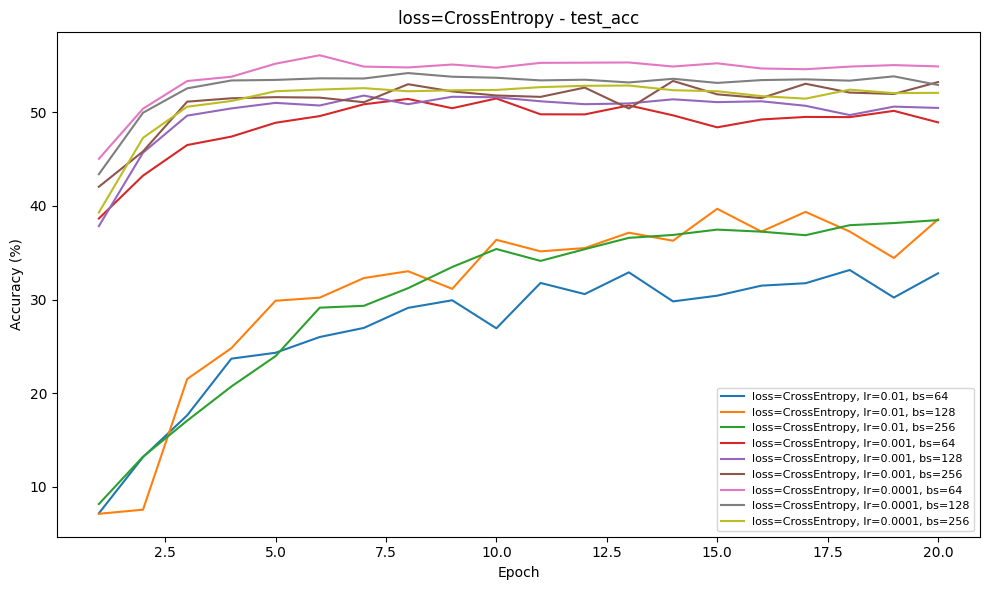

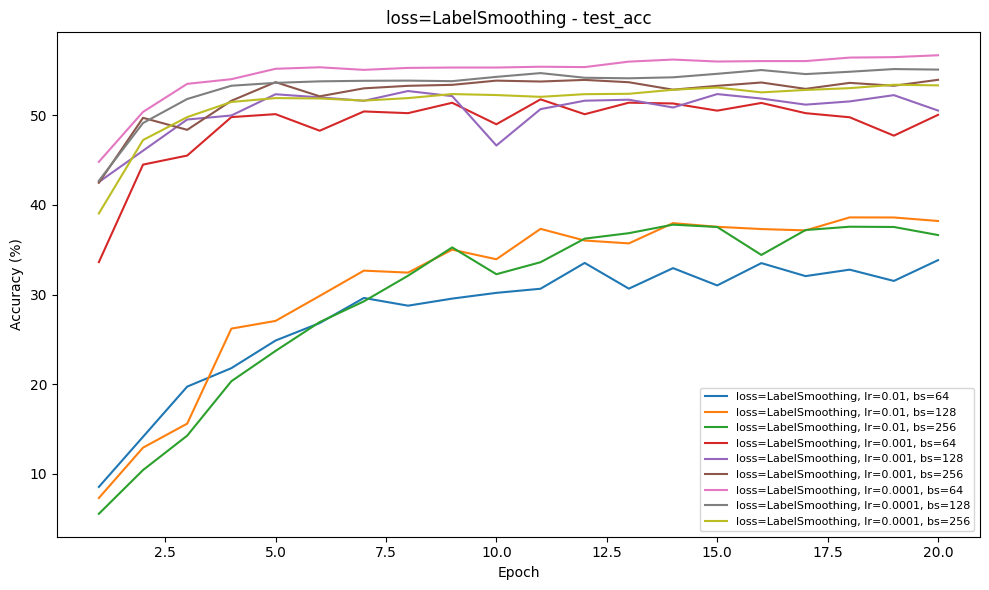

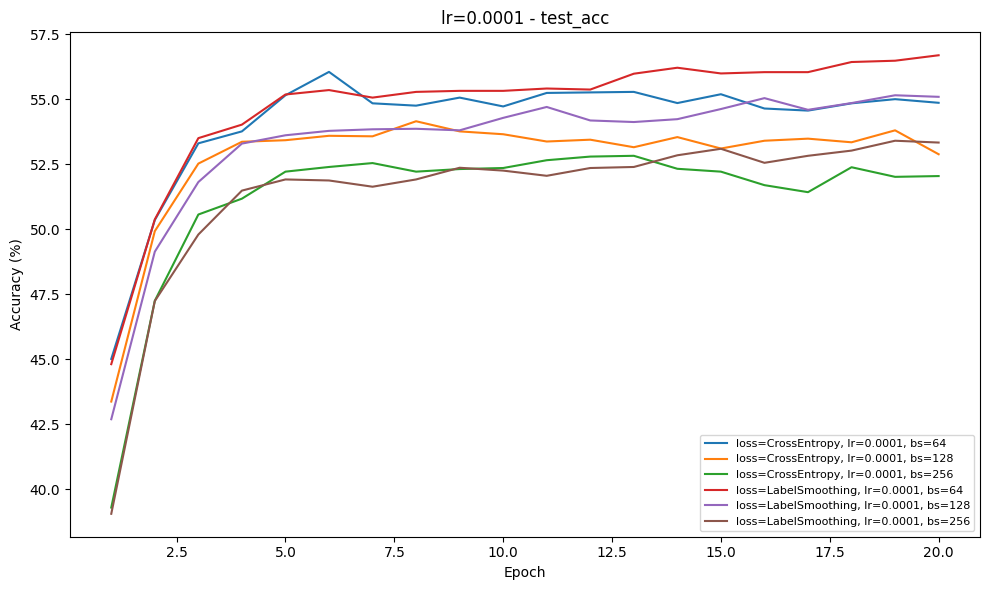

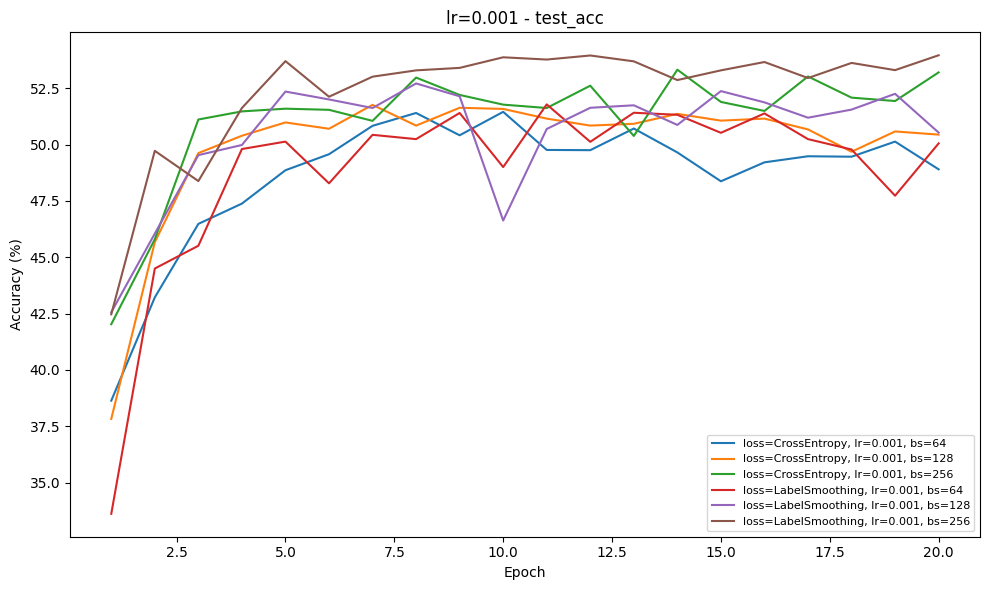

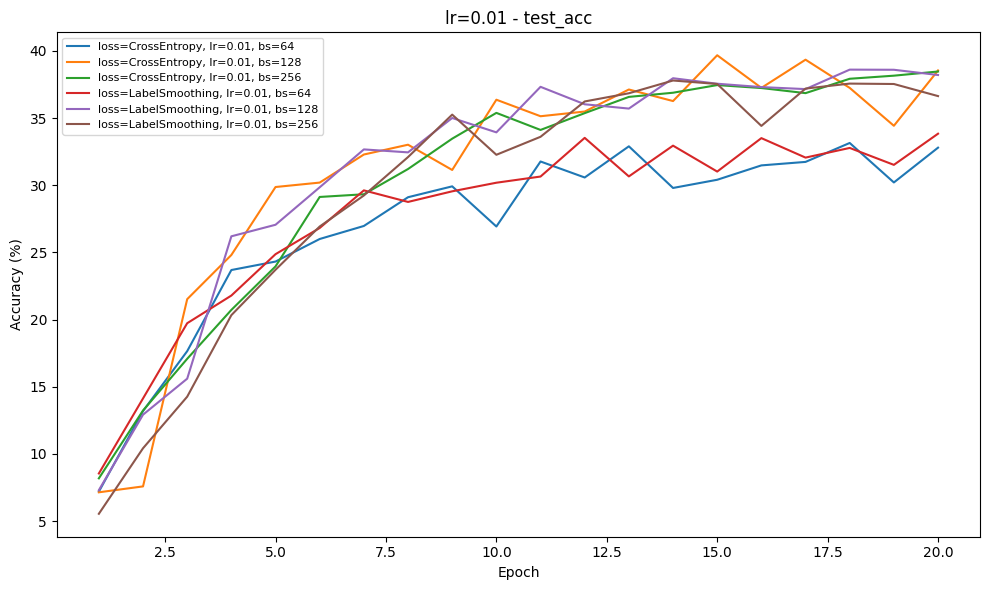

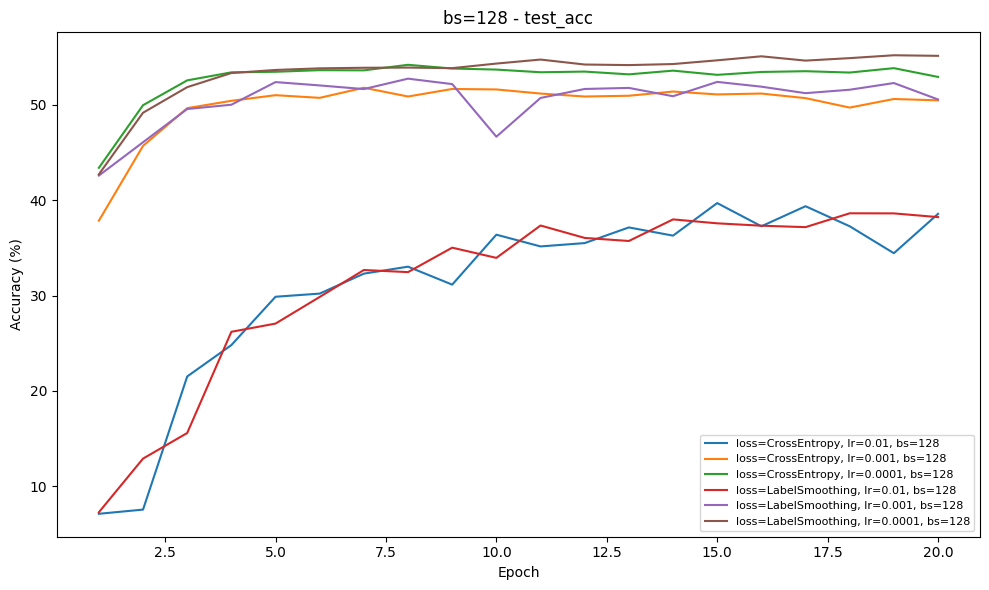

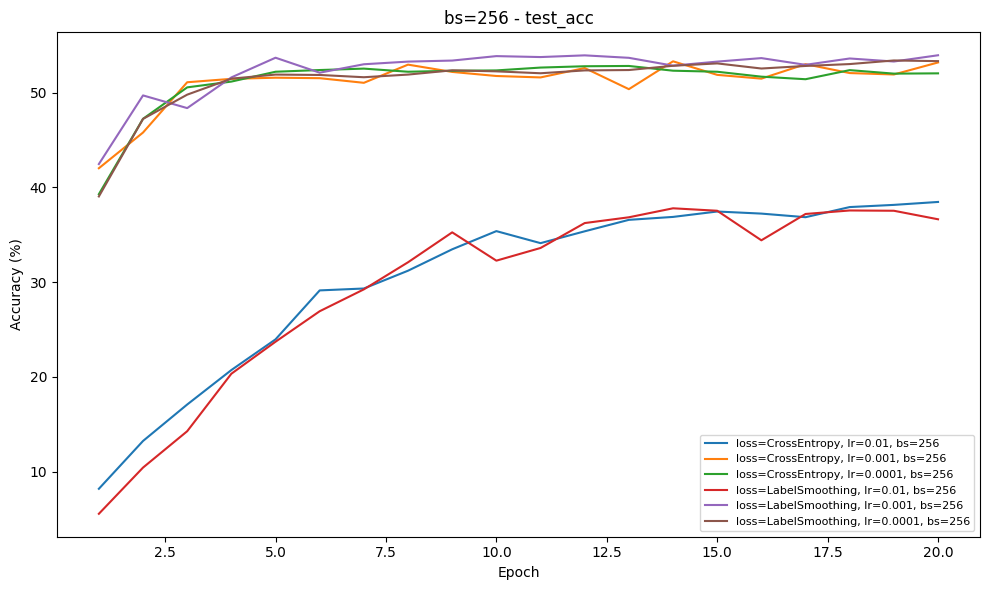

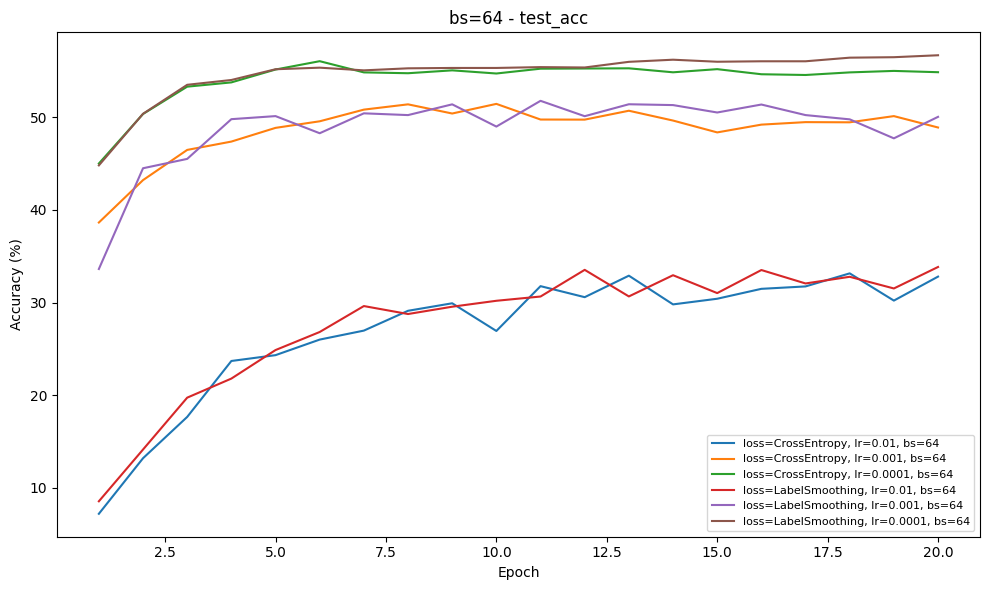

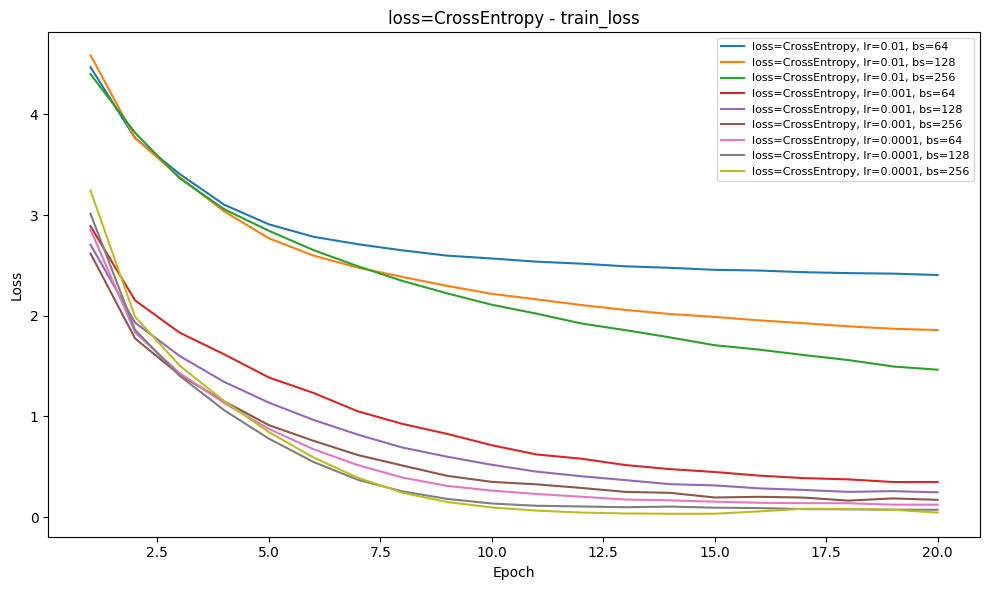

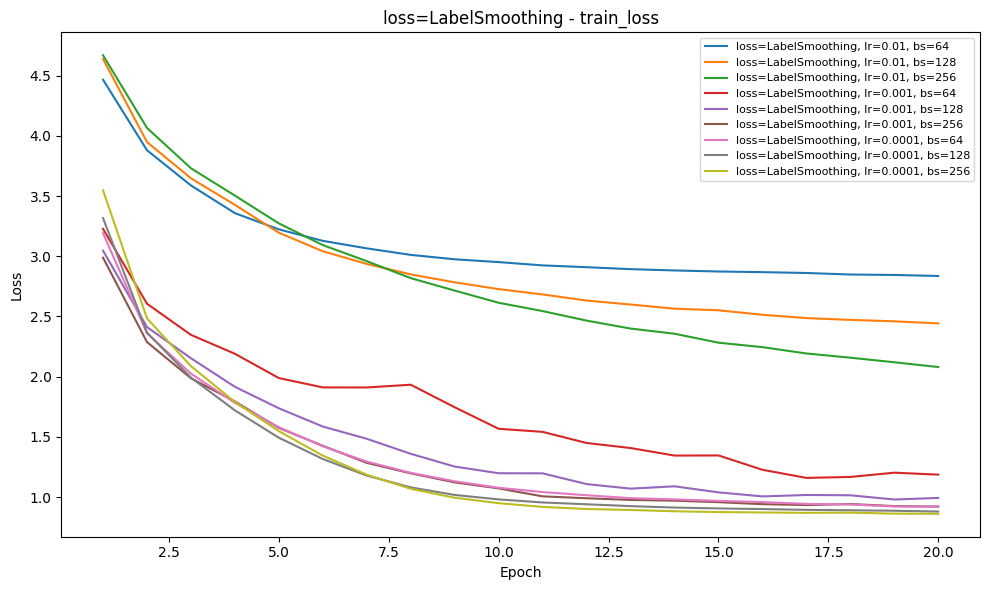

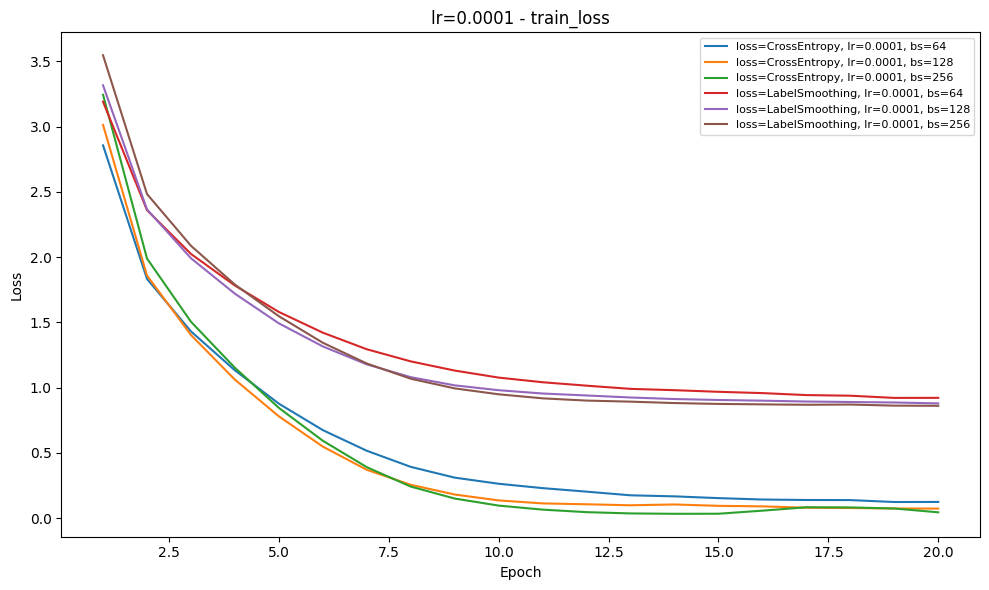

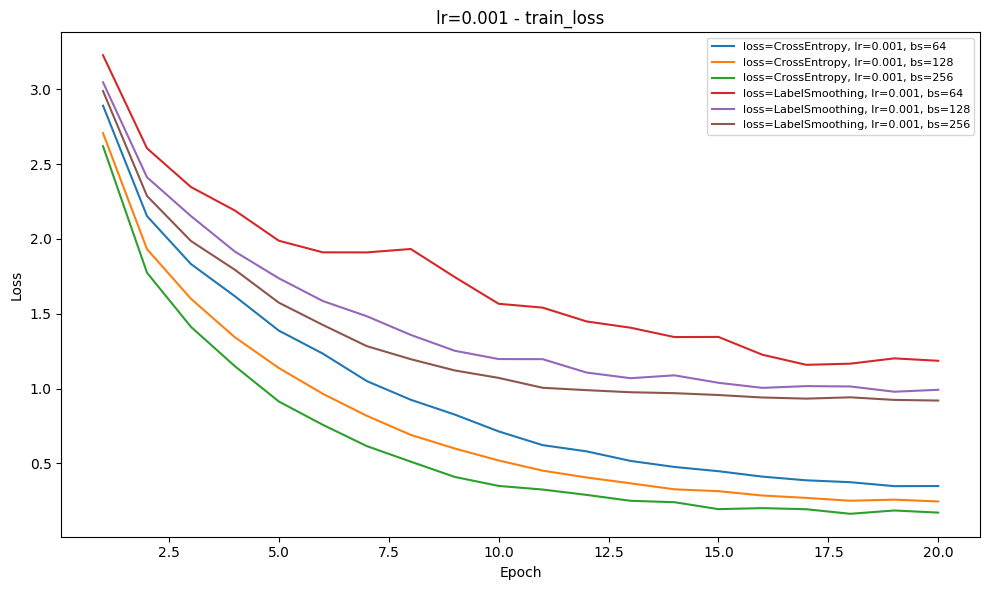

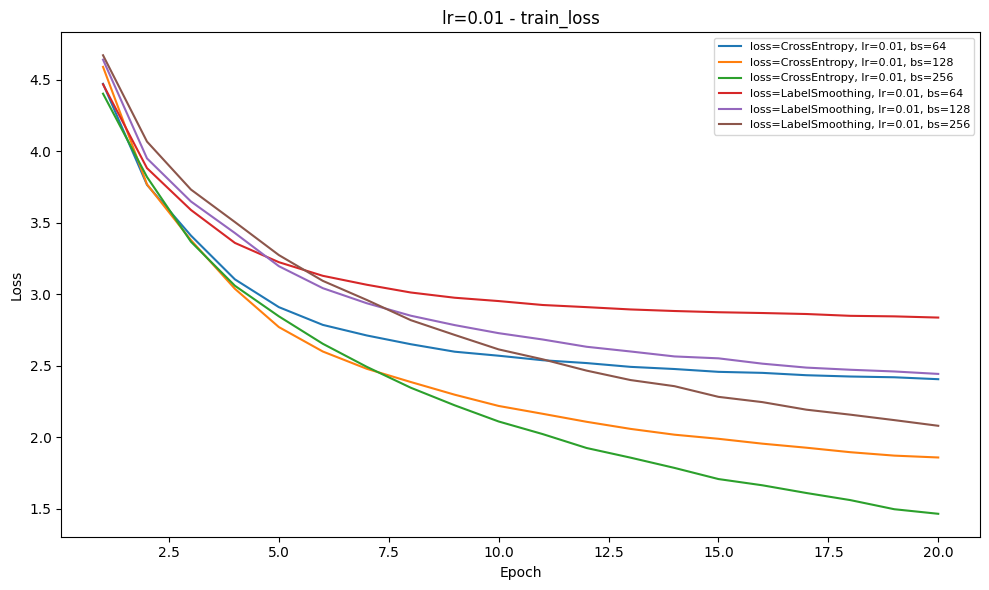

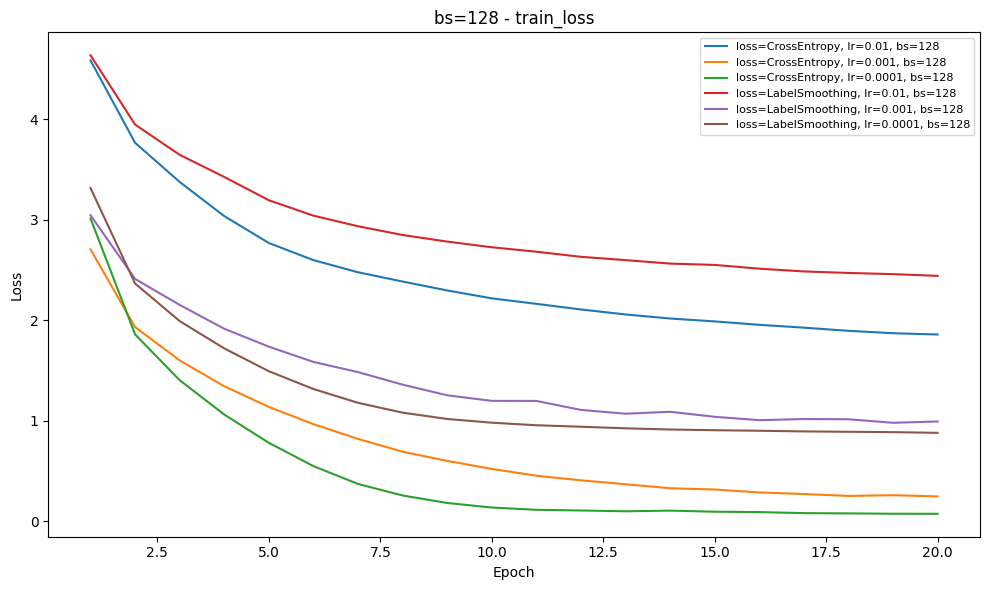

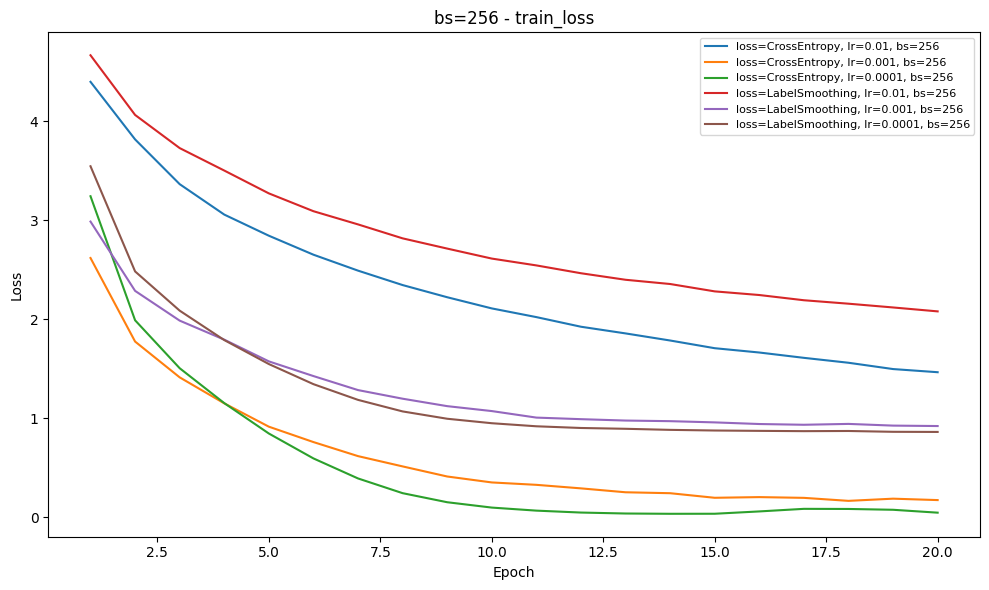

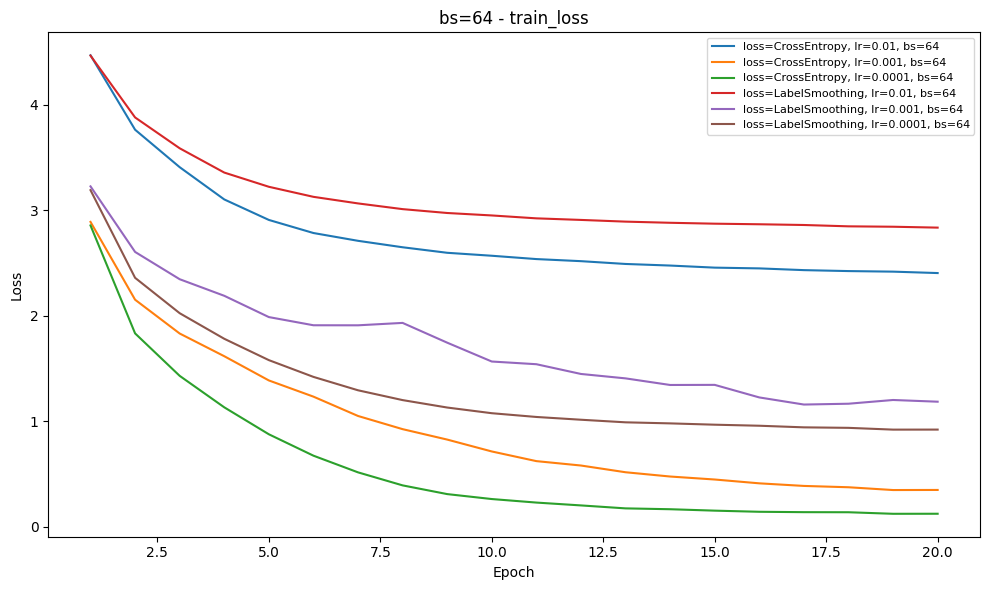

In [31]:
plot_grouped_results(results, metric="test_acc", group_by="loss")
plot_grouped_results(results, metric="test_acc", group_by="lr")
plot_grouped_results(results, metric="test_acc", group_by="bs")

plot_grouped_results(results, metric="train_loss", group_by="loss")
plot_grouped_results(results, metric="train_loss", group_by="lr")
plot_grouped_results(results, metric="train_loss", group_by="bs")

Epoch 1: Test Acc=44.34%
Epoch 2: Test Acc=50.71%
Epoch 3: Test Acc=53.64%
Epoch 4: Test Acc=53.69%
Epoch 5: Test Acc=54.99%
Epoch 6: Test Acc=54.66%
Epoch 7: Test Acc=55.20%
Epoch 8: Test Acc=55.67%
Epoch 9: Test Acc=55.44%
Epoch 10: Test Acc=55.60%
Epoch 11: Test Acc=55.67%
Epoch 12: Test Acc=55.50%
Epoch 13: Test Acc=55.49%
Epoch 14: Test Acc=55.67%
Epoch 15: Test Acc=55.79%
Epoch 16: Test Acc=55.72%
Epoch 17: Test Acc=55.81%
Epoch 18: Test Acc=56.19%
Epoch 19: Test Acc=56.50%
Epoch 20: Test Acc=56.17%


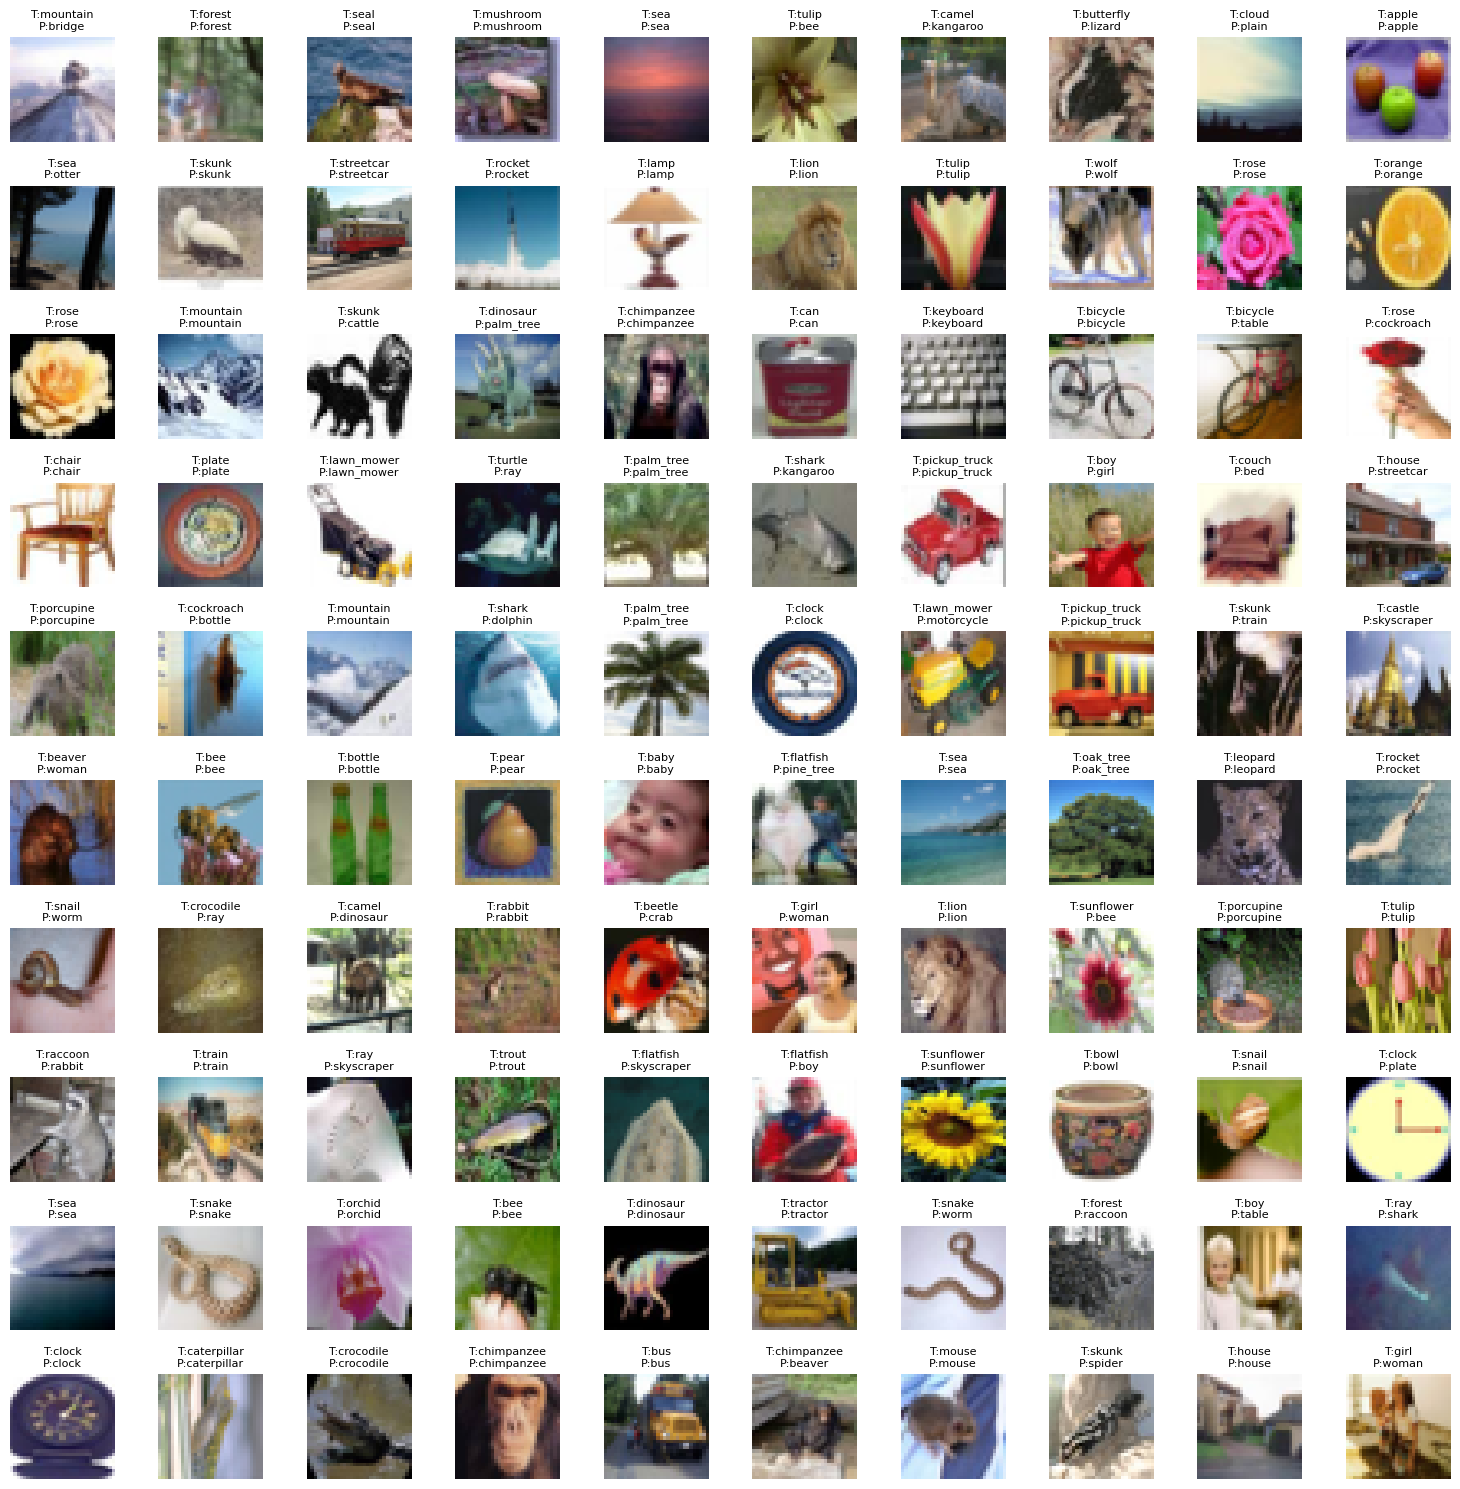

In [34]:
# 1. 数据加载 (优选参数: batch=64)
trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=4)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=4)

classes = trainset.classes  # CIFAR-100 类别名称

# 2. 定义模型（优选参数：LabelSmoothing + lr=0.0001）
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(512, 100)
model = model.to(device)

loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.05)

# 3. 训练模型（20个epoch）
epochs = 20
for epoch in range(epochs):
    model.train()
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

    # 测试集准确率
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Test Acc={acc:.2f}%")

# 4. 反标准化函数
mean = [0.5071, 0.4867, 0.4408]
std = [0.2675, 0.2565, 0.2761]
def unnormalize(img):
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0,1)

# 5. 可视化前100个预测结果
def visualize_predictions(model, testloader, classes, device, num_samples=100):
    model.eval()
    images, labels, preds = [], [], []
    with torch.no_grad():
        count = 0
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            for i in range(inputs.size(0)):
                if count < num_samples:
                    images.append(inputs[i].cpu())
                    labels.append(targets[i].cpu().item())
                    preds.append(predicted[i].cpu().item())
                    count += 1
                else:
                    break
            if count >= num_samples:
                break

    fig, axes = plt.subplots(10, 10, figsize=(15, 15))
    for i, ax in enumerate(axes.flat):
        img = unnormalize(images[i]).permute(1, 2, 0)  # 反标准化 + CHW->HWC
        ax.imshow(img)
        ax.set_title(f"T:{classes[labels[i]]}\nP:{classes[preds[i]]}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# 调用可视化函数
visualize_predictions(model, testloader, classes, device, num_samples=100)